In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")

In [11]:
import pandas as pd

file_path = "/content/drive/MyDrive/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(file_path)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [12]:
# Number of rows and columns
print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# General information
print("\nDataset Information:")
df.info()


Number of Rows: 299
Number of Columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Dataset Information:
<class 'pandas.core.

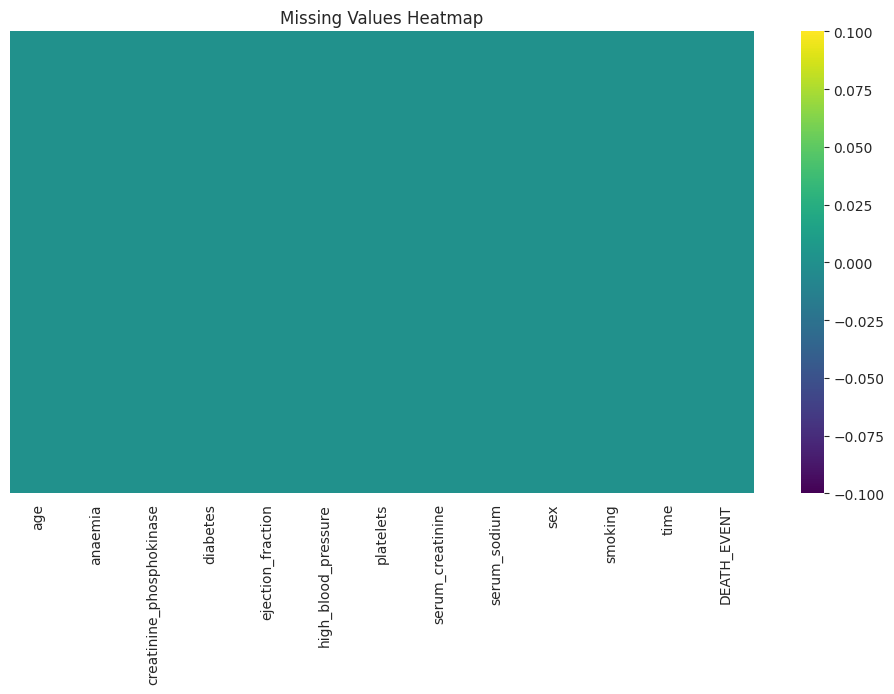

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cmap='viridis',
    cbar=True,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.show()

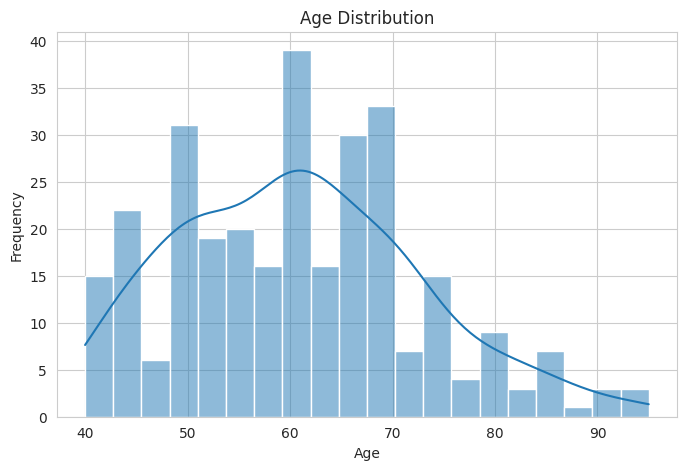

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'],
             bins=20,
             kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

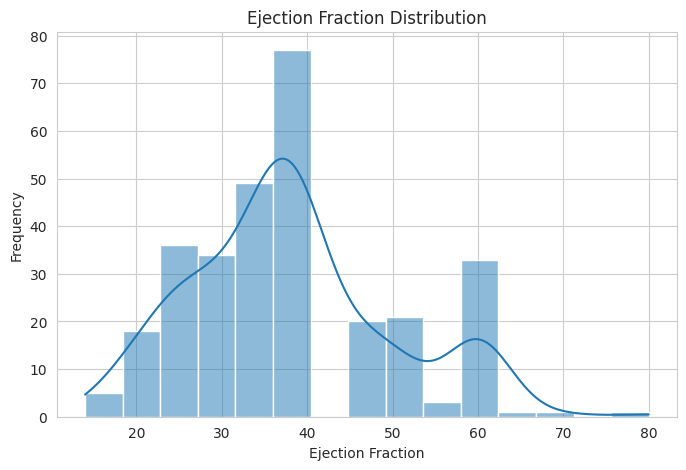

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['ejection_fraction'],
             bins=15,
             kde=True)

plt.title("Ejection Fraction Distribution")
plt.xlabel("Ejection Fraction")
plt.ylabel("Frequency")

plt.show()

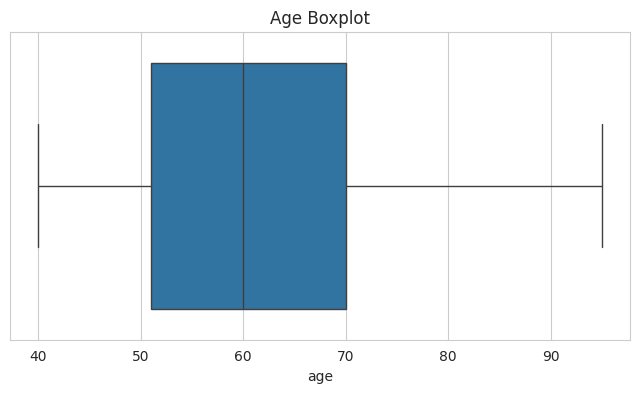

In [16]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['age'])

plt.title("Age Boxplot")

plt.show()

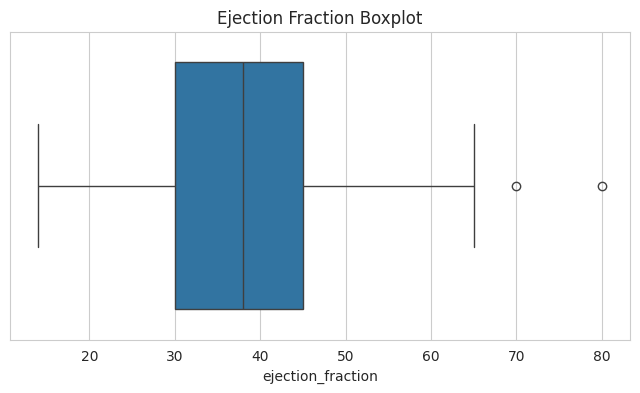

In [17]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['ejection_fraction'])

plt.title("Ejection Fraction Boxplot")

plt.show()

In [18]:
print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [19]:
df_before_outlier = df.copy()

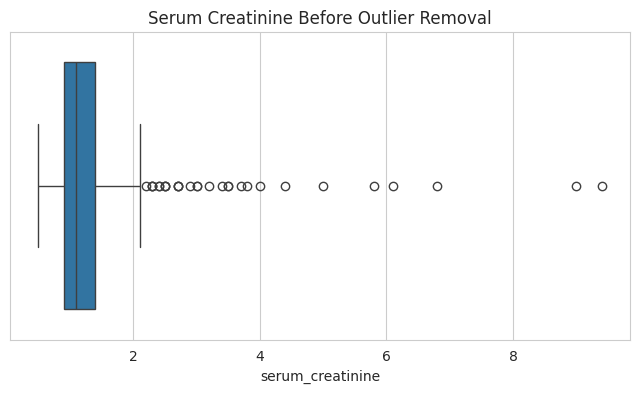

In [20]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['serum_creatinine'])
plt.title("Serum Creatinine Before Outlier Removal")
plt.show()

In [21]:
def remove_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[
        (data[column] >= lower) &
        (data[column] <= upper)
    ]

In [22]:
outlier_cols = [
    'age',
    'ejection_fraction',
    'platelets',
    'serum_creatinine'
]

for col in outlier_cols:
    df = remove_outliers(df, col)

print("Shape After Outlier Removal:")
print(df.shape)

Shape After Outlier Removal:
(251, 13)


In [23]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    print(col, ":", (df[col] < 0).sum())

age : 0
anaemia : 0
creatinine_phosphokinase : 0
diabetes : 0
ejection_fraction : 0
high_blood_pressure : 0
platelets : 0
serum_creatinine : 0
serum_sodium : 0
sex : 0
smoking : 0
time : 0
DEATH_EVENT : 0


In [24]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0,40,60,120],
    labels=['<40','40-60','>60']
)

df[['age','age_group']].head()

,age,age_group
0,75.0,>60
1,55.0,40-60
2,65.0,>60
3,50.0,40-60
5,90.0,>60


In [25]:
df['risk_score'] = (
    (df['serum_creatinine'] / df['serum_creatinine'].max())
    *
    (df['ejection_fraction'] / df['ejection_fraction'].max())
)

df[['risk_score']].head()

,risk_score
0,0.278388
1,0.306227
2,0.190476
3,0.278388
5,0.615385


In [26]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['age_group'] = encoder.fit_transform(
    df['age_group'].astype(str)
)

In [27]:
print(df[['sex','smoking']].head())

   sex  smoking
0    1        0
1    1        0
2    1        1
3    1        0
5    1        1


In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scale_cols = [
    'age',
    'platelets',
    'serum_creatinine',
    'ejection_fraction'
]

df[scale_cols] = scaler.fit_transform(
    df[scale_cols]
)

df[scale_cols].head()

,age,platelets,serum_creatinine,ejection_fraction
0,0.636364,0.523529,0.875,0.117647
1,0.272727,0.518700,0.375,0.470588
2,0.454545,0.220588,0.500,0.117647
3,0.181818,0.361765,0.875,0.117647
5,0.909091,0.344118,1.000,0.509804


In [29]:
print("Before Cleaning Statistics")
df_before_outlier.describe()

Before Cleaning Statistics


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [30]:
print("After Cleaning Statistics")
df.describe()

After Cleaning Statistics


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,age_group,risk_score
count,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000
mean,0.369238,0.438247,593.274900,0.414343,0.469260,0.370518,0.495984,0.393825,136.908367,0.657371,0.326693,133.454183,0.278884,0.944223,0.308542
std,0.216335,0.497163,1003.969067,0.493592,0.226291,0.483908,0.200093,0.209199,4.210887,0.475537,0.469941,76.353761,0.449347,0.986345,0.118735
min,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,113.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.082051
25%,0.181818,0.000000,122.000000,0.000000,0.313725,0.000000,0.373529,0.250000,135.000000,0.000000,0.000000,78.000000,0.000000,0.000000,0.219780
50%,0.363636,0.000000,249.000000,0.000000,0.470588,0.000000,0.517647,0.375000,137.000000,1.000000,0.000000,120.000000,0.000000,0.000000,0.285714
75%,0.527273,1.000000,582.000000,1.000000,0.607843,1.000000,0.617647,0.468750,140.000000,1.000000,1.000000,205.000000,1.000000,2.000000,0.366300
max,1.000000,1.000000,7861.000000,1.000000,1.000000,1.000000,1.000000,1.000000,148.000000,1.000000,1.000000,285.000000,1.000000,2.000000,0.765568


In [31]:
summary_stats = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Std Dev': df.std(numeric_only=True)
})

summary_stats

,Mean,Median,Std Dev
age,0.369238,0.363636,0.216335
anaemia,0.438247,0.000000,0.497163
creatinine_phosphokinase,593.274900,249.000000,1003.969067
diabetes,0.414343,0.000000,0.493592
ejection_fraction,0.469260,0.470588,0.226291
high_blood_pressure,0.370518,0.000000,0.483908
platelets,0.495984,0.517647,0.200093
serum_creatinine,0.393825,0.375000,0.209199
serum_sodium,136.908367,137.000000,4.210887
sex,0.657371,1.000000,0.475537


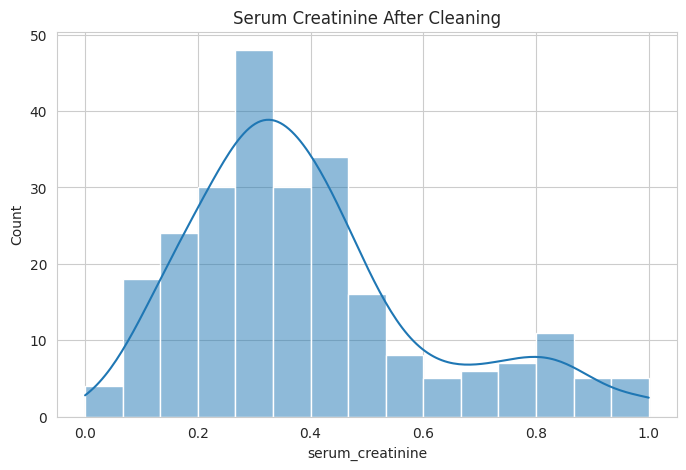

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['serum_creatinine'],
    bins=15,
    kde=True
)

plt.title("Serum Creatinine After Cleaning")

plt.show()

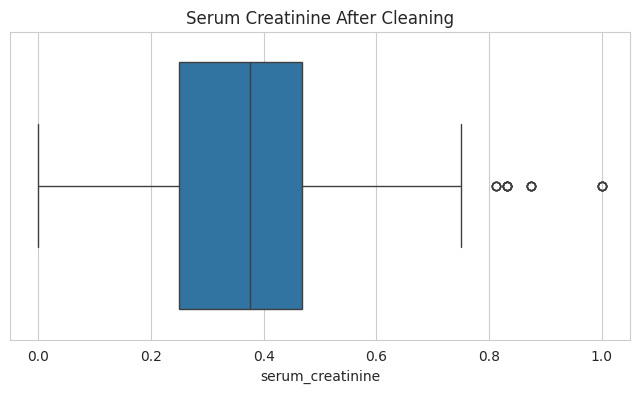

In [33]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['serum_creatinine'])

plt.title("Serum Creatinine After Cleaning")

plt.show()

In [34]:
print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
age_group                   0
risk_score                  0
dtype: int64


In [35]:
if df.isnull().sum().sum() == 0:
    print("No Missing Values Remaining")
else:
    print("Missing Values Still Exist")

No Missing Values Remaining
